# A Minimal NDT Training Setup on Perich & Miller 2018

<html>
<img src="https://camo.githubusercontent.com/38004ff525c31b5088bbac056320ce63b4caaf23d8d0d5aea30b8cf7deba7b73/68747470733a2f2f746f7263682d627261696e2e72656164746865646f63732e696f2f656e2f6c61746573742f5f7374617469632f746f7263685f627261696e5f6c6f676f2e706e67", width="100px">
</html>


This example walks through a minimal training pipeline for decoding 2D cursor velocity from motor cortex spiking activity, using a center-out reaching recording from the [Perich & Miller 2018](https://doi.org/10.1016/j.neuron.2018.08.037) dataset.

It is intended as a starting point for new users of `torch_brain` and `brainsets`, and shows how to:
1. Build a custom `Dataset` on top of a `brainsets` recording.
2. Sample fixed-length windows from continuous recordings using `RandomFixedWindowSampler` and `SequentialFixedWindowSampler`.
3. Train an NDT (Neural Data Transformer) decoder.


> ⚠ **Note:**
> Although this notebook will run on a CPU, it is recommended that you use a GPU runtime.
> If you're on Google Colab, do: Runtime > Change runtime type > T4 GPU


In [ ]:
from pynwb import NWBHDF5IO
import numpy as np

fpath = "/home/aandre1/ws/torch_brain/data/raw/perich_miller_population_2018/sub-C/sub-C_ses-CO-20161011_behavior+ecephys.nwb"

with NWBHDF5IO(fpath, "r") as io:
    nwbfile = io.read()
    timestamps = nwbfile.processing["behavior"]["Position"]["cursor_pos"].timestamps[:]

dt = np.diff(timestamps)
expected_dt = np.median(dt)  # use median as ground truth

duplicates = np.where(dt < expected_dt * 0.5)[0]
missing = np.where(dt > expected_dt * 1.5)[0]

print(f"Expected dt: {expected_dt:.6f}s  ({1/expected_dt:.1f} Hz)")
print(f"\nDuplicates ({len(duplicates)}):")
for i in duplicates:
    print(f"  idx {i}: t={timestamps[i]:.6f}  dt={dt[i]:.6f}")

print(f"\nMissing steps ({len(missing)}):")
for i in missing:
    n_missing = round(dt[i] / expected_dt) - 1
    print(f"  idx {i}: t={timestamps[i]:.6f}  dt={dt[i]:.6f}  (~{n_missing} missing)")

SyntaxError: unterminated string literal (detected at line 4) (3554986037.py, line 4)

## Setup

Install dependencies:


In [174]:
# !pip install scikit-learn matplotlib torch git+https://github.com/neuro-galaxy/torch_brain

And preprocess the dataset using `brainsets`:


In [175]:
# !brainsets prepare perich_miller_population_2018 --raw-dir data/raw --processed-dir data/processed

In [176]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Hyperparameters


In [177]:
# Hyperparameters (feel free to play with these)
BIN_SIZE = 0.01  # seconds per spike-count bin
WINDOW_LENGTH = 1.0  # seconds of context fed to the model
BATCH_SIZE = 32
EPOCHS = 1000
LR = 5e-4
SEED = 42

## Defining a Simple & Custom Dataset

`brainsets` provides a `PerichMillerPopulation2018` base class that handles file I/O for this recording.

We subclass it and define two things on top:
- **`get_sampling_intervals`**: Returns the time windows the sampler may draw from, intersected with the spike domain and the appropriate train/validation split.
- **`__getitem__`**: Given a sampled time window (a `DatasetIndex`), turns it into model-compatible tensors.


In [178]:
from torch_brain.datasets import DatasetIndex, PerichMillerPopulation2018
from torch_brain.utils import bin_spikes


class SimplePerichMillerPopulationDataset(PerichMillerPopulation2018):
    def __init__(
        self,
        root: str,
        split: str,
        bin_size: float,
        recording_ids: list[str] | None = None,
    ):
        super().__init__(root=root, recording_ids=recording_ids)
        assert split in ("train", "valid")

        self.split = split
        self.bin_size = bin_size
        self.num_units = len(self.get_unit_ids())

    # Contract between Datasets and Samplers:
    # get_sampling_intervals() returns {recording_id: Interval} listing
    # the windows the sampler may draw from.
    def get_sampling_intervals(self, *_args, **_kwargs):
        intervals = super().get_sampling_intervals()

        for rid, interval in intervals.items():
            recording = self.get_recording(rid)

            spikes_domain = recording.spikes.domain
            vel_domain = recording.cursor.domain
            split_domain = recording.get_nested_attribute(f"{self.split}_domain")

            intervals[rid] = interval & spikes_domain & vel_domain & split_domain

        return intervals

    def get_num_units_per_recording(self) -> dict[str, int]:
        return {
            rid: len(self.get_recording(rid).units)
            for rid in sorted(self.recording_ids)
        }

    # `index` is a DatasetIndex(recording_id, start, end) produced by the sampler.
    def __getitem__(self, index: DatasetIndex):
        data = super().__getitem__(index)

        # Spikes are an irregular event stream — bin them into a regular grid.
        X = bin_spikes(data.spikes, num_units=len(data.units), bin_size=self.bin_size)
        X = torch.from_numpy(X).float()  # shape: (num_bins, num_units)

        rid = data.session.id

        if len(data.cursor.vel) != 100:
            print(data.cursor.domain.end - data.cursor.domain.start)
            print(rid)
            print(data.cursor.domain.start)
            print(data.cursor.domain.end)
            print(data.cursor)
            print(data.cursor.timestamps)
            print(data.cursor.timestamps[-1] - data.cursor.timestamps[0])

            import numpy as np
            import matplotlib.pyplot as plt

            timestamps = data.cursor.timestamps

            diffs = np.diff(timestamps)
            expected_dt = 0.01

            fig, ax = plt.subplots(figsize=(12, 3))
            ax.plot(timestamps[1:], diffs, color="steelblue", linewidth=0.8, label="dt")
            ax.axhline(
                expected_dt,
                color="gray",
                linestyle="--",
                linewidth=0.8,
                label="expected dt",
            )
            ax.scatter(
                timestamps[1:][diffs < expected_dt * 0.5],
                diffs[diffs < expected_dt * 0.5],
                color="red",
                zorder=5,
                label="duplicate",
            )
            ax.scatter(
                timestamps[1:][diffs > expected_dt * 1.5],
                diffs[diffs > expected_dt * 1.5],
                color="orange",
                zorder=5,
                label="missing",
            )
            ax.set_xlabel("time (s)")
            ax.set_ylabel("dt (s)")
            ax.legend()
            plt.tight_layout()
            plt.show()

        # Cursor velocity is a regularly-sampled signal; divide to normalize.
        Y = data.cursor.vel / 20.0
        Y = torch.from_numpy(Y).float()  # shape: (out_samples, 2)
        return X, rid, Y

## Creating the Datasets, Samplers, and DataLoaders

💡 The main pattern for data pipelines in `torch_brain`:
- **Dataset** tells the sampler *where sampling is allowed*,
- **Sampler** decides *what* samples to load (by emitting `DatasetIndex` objects), and
- **DataLoader** batches the samples as usual.

For continuous recordings (no natural trial boundaries), `RandomFixedWindowSampler` draws random windows of a fixed length during training, while `SequentialFixedWindowSampler` tiles the validation data non-overlappingly.


In [179]:
from collections.abc import Iterator

import torch
from torch_brain.dataset import DatasetIndex


class SessionBatchSampler(torch.utils.data.Sampler[list[DatasetIndex]]):
    """Wraps any sampler yielding :class:`DatasetIndex` and groups its output
    into per-session batches.

    All indices in a batch share the same session id. The inner sampler controls
    the order of indices within each session; ``shuffle_batches`` controls the
    order of batches across sessions.

    Args:
        sampler: Inner sampler whose ``__iter__`` yields :class:`DatasetIndex` objects.
        batch_size: Number of samples per batch.
        shuffle_batches: Whether to shuffle the final batch order. Defaults to False.
        generator: Generator used when shuffling batches. Defaults to None.
        drop_last: Whether to drop the last incomplete batch per session.
            Defaults to True.
    """

    def __init__(
        self,
        sampler: torch.utils.data.Sampler,
        batch_size: int,
        *,
        shuffle_batches: bool = False,
        generator: torch.Generator | None = None,
        drop_last: bool = True,
    ):
        if batch_size <= 0:
            raise ValueError("batch_size must be positive.")
        self.sampler = sampler
        self.batch_size = batch_size
        self.shuffle_batches = shuffle_batches
        self.generator = generator
        self.drop_last = drop_last
        self._batches_cache: list[list[DatasetIndex]] | None = None

    def _build_batches(self) -> list[list[DatasetIndex]]:
        indices_by_session: dict[str, list[DatasetIndex]] = {}
        for idx in self.sampler:
            session_id = idx.recording_id
            if session_id not in indices_by_session:
                indices_by_session[session_id] = []
            indices_by_session[session_id].append(idx)

        batches: list[list[DatasetIndex]] = []
        for indices in indices_by_session.values():
            max_len = len(indices)
            if self.drop_last:
                max_len = (max_len // self.batch_size) * self.batch_size
            for i in range(0, max_len, self.batch_size):
                batch = indices[i : i + self.batch_size]
                if len(batch) == self.batch_size or not self.drop_last:
                    batches.append(batch)

        return batches

    def _prepare_cache(self) -> None:
        if self._batches_cache is None:
            self._batches_cache = self._build_batches()

    def __len__(self) -> int:
        self._prepare_cache()
        return len(self._batches_cache)

    def __iter__(self) -> Iterator[list[DatasetIndex]]:
        self._prepare_cache()
        batches = self._batches_cache
        self._batches_cache = None  # reset so next epoch rebuilds

        if self.shuffle_batches and batches:
            for idx in torch.randperm(len(batches), generator=self.generator).tolist():
                yield batches[idx]
        else:
            yield from batches

    def set_epoch(self, epoch: int) -> None:
        """Pass the epoch to the underlying sampler if it supports it."""
        if hasattr(self.sampler, "set_epoch"):
            self.sampler.set_epoch(epoch)

In [180]:
from torch.utils.data import DataLoader

from torch_brain.samplers import RandomFixedWindowSampler, SequentialFixedWindowSampler

DATA_ROOT = "../../../../data/processed"

train_ds = SimplePerichMillerPopulationDataset(
    DATA_ROOT, split="train", bin_size=BIN_SIZE
)
train_sampler = RandomFixedWindowSampler(
    sampling_intervals=train_ds.get_sampling_intervals(),
    window_length=WINDOW_LENGTH,
    generator=torch.Generator().manual_seed(42),
    drop_short=True,
)
train_batch_sampler = SessionBatchSampler(
    sampler=train_sampler,
    batch_size=BATCH_SIZE,
    shuffle_batches=True,
    generator=torch.Generator().manual_seed(42),
)
train_loader = DataLoader(train_ds, batch_sampler=train_batch_sampler, num_workers=8)

val_ds = SimplePerichMillerPopulationDataset(
    DATA_ROOT, split="valid", bin_size=BIN_SIZE
)
val_sampler = SequentialFixedWindowSampler(
    sampling_intervals=val_ds.get_sampling_intervals(),
    window_length=WINDOW_LENGTH,
    drop_short=True,
)
val_batch_sampler = SessionBatchSampler(
    sampler=val_sampler,
    batch_size=BATCH_SIZE,
)
val_loader = DataLoader(val_ds, batch_sampler=val_batch_sampler, num_workers=8)

print(f"Number of units:     {train_ds.num_units}")
print(f"Training windows:    {len(train_sampler)}")
print(f"Validation windows:  {len(val_sampler)}")

Number of units:     10410
Training windows:    107778
Validation windows:  11757


Let's peek at a single sample to confirm the shapes match what we expect, and visualize the binned spikes (input) and cursor velocity (target) for one window.


First sample:
    recording_id: c_20150309_center_out_reaching
    start: 841.661 s,  end: 842.661 s

X shape: (100, 74)  (num_bins, num_units)
Y shape: (100, 2)  (out_samples, 2)


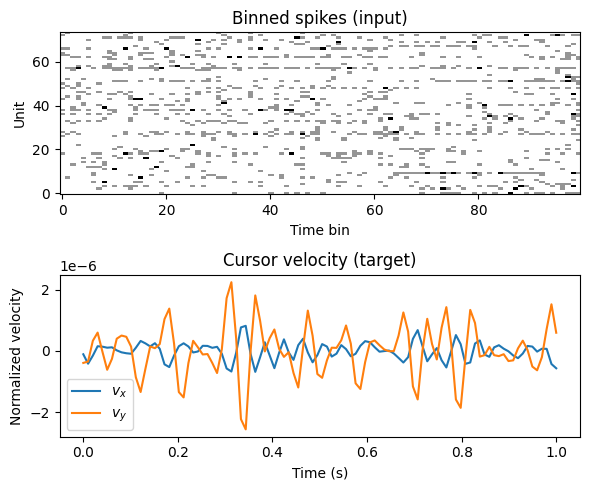

In [181]:
first_index = next(iter(train_sampler))
print(
    f"First sample:\n"
    f"    recording_id: {first_index.recording_id}\n"
    f"    start: {first_index.start:.3f} s,  end: {first_index.end:.3f} s\n"
)

X, _, Y = train_ds[first_index]
print(f"X shape: {tuple(X.shape)}  (num_bins, num_units)")
print(f"Y shape: {tuple(Y.shape)}  (out_samples, 2)")

fig, axes = plt.subplots(2, 1, figsize=(6, 5))

axes[0].imshow(
    X.T.numpy(), aspect="auto", cmap="Greys", origin="lower", interpolation="nearest"
)
axes[0].set_title("Binned spikes (input)")
axes[0].set_xlabel("Time bin")
axes[0].set_ylabel("Unit")

t = np.linspace(0, WINDOW_LENGTH, Y.shape[0])
axes[1].plot(t, Y[:, 0].numpy(), label="$v_x$")
axes[1].plot(t, Y[:, 1].numpy(), label="$v_y$")
axes[1].set_title("Cursor velocity (target)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Normalized velocity")
axes[1].legend()

plt.tight_layout()
plt.show()

## The Model

NDT (Neural Data Transformer) is a small transformer encoder that operates on binned spike trains.

It maps `(batch, num_bins, num_units)` → `(batch, num_bins, output_dim)` via:
1. A linear projection (`in_stitch`) from `num_units` → `hidden_dim`,
2. Learned positional embeddings added to the projected spikes,
3. A standard transformer encoder, and
4. A per-timestep linear readout (`out_stitch`).


In [182]:
class NDT(nn.Module):
    def __init__(
        self,
        hidden_dim: int,
        encoder_num_heads: int,
        encoder_ffn_factor: int,
        encoder_num_layers: int,
        dropout: float,
        num_units_per_recording: dict[str, int],
        ctx_window: float,
        bin_size: float,
        output_dim: int,
    ):
        super().__init__()

        num_bins = int(ctx_window / bin_size)
        self.position_emb = nn.Embedding(num_bins, hidden_dim)

        self.in_stitch = nn.ModuleDict(
            {
                rid: nn.Linear(num_units, hidden_dim, bias=False)
                for rid, num_units in num_units_per_recording.items()
            }
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=encoder_num_heads,
            dim_feedforward=hidden_dim * encoder_ffn_factor,
            dropout=dropout,
            activation=nn.ReLU(),
            norm_first=True,
            batch_first=True,
        )
        self.encoder = nn.Sequential(
            nn.Dropout(dropout),
            nn.TransformerEncoder(
                encoder_layer=encoder_layer,
                num_layers=encoder_num_layers,
                norm=nn.LayerNorm(hidden_dim),
            ),
            nn.Dropout(dropout),
        )

        self.out_stitch = nn.Linear(hidden_dim, output_dim)

    def forward(self, spikes: Tensor, rid: str) -> Tensor:
        B, T, N = spikes.size()
        dev = spikes.device

        spikes_emb = self.in_stitch[rid](spikes)  # (B, T, D_in) -> (B, T, D)

        positions = torch.arange(T, device=dev).unsqueeze(0).expand(B, -1)  # (B, T)
        pos_emb = self.position_emb(positions)  # (B, T) -> (B, T, D)

        emb = spikes_emb + pos_emb  # (B, T, D)
        latent = self.encoder(emb)  # (B, T, D)

        return self.out_stitch(latent)  # (B, T, D) -> (B, T, D_out)

### Instantiating the model


In [183]:
model = NDT(
    hidden_dim=128,
    encoder_num_heads=8,
    encoder_ffn_factor=2,
    encoder_num_layers=4,
    dropout=0.1,
    num_units_per_recording=train_ds.get_num_units_per_recording(),
    ctx_window=WINDOW_LENGTH,
    bin_size=BIN_SIZE,
    output_dim=2,
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
print(model)

Trainable parameters: 1,875,714
NDT(
  (position_emb): Embedding(100, 128)
  (in_stitch): ModuleDict(
    (c_20131003_center_out_reaching): Linear(in_features=71, out_features=128, bias=False)
    (c_20131009_random_target_reaching): Linear(in_features=74, out_features=128, bias=False)
    (c_20131010_random_target_reaching): Linear(in_features=74, out_features=128, bias=False)
    (c_20131011_random_target_reaching): Linear(in_features=88, out_features=128, bias=False)
    (c_20131022_center_out_reaching): Linear(in_features=41, out_features=128, bias=False)
    (c_20131023_center_out_reaching): Linear(in_features=61, out_features=128, bias=False)
    (c_20131028_random_target_reaching): Linear(in_features=77, out_features=128, bias=False)
    (c_20131029_random_target_reaching): Linear(in_features=67, out_features=128, bias=False)
    (c_20131031_center_out_reaching): Linear(in_features=49, out_features=128, bias=False)
    (c_20131101_center_out_reaching): Linear(in_features=41, out

/tmp/ipykernel_1000509/2324104704.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


## Training

A standard PyTorch loop. MSE loss against cursor velocity, AdamW optimizer, R² evaluated on the validation set at the end of each epoch.


  0%|          | 0/1000 [00:00<?, ?it/s]

[1.]
c_20161011_center_out_reaching
[0.]
[1.]
LazyIrregularTimeSeries(
  timestamps=[101],
  acc=<HDF5 dataset "acc": shape (90235, 2), type "<f8">,
  pos=<HDF5 dataset "pos": shape (90235, 2), type "<f8">,
  vel=[101, 2]
)
[0.0038316 0.0138316 0.0238316 0.0338316 0.0438316 0.0538316 0.0638316
 0.0738316 0.0838316 0.0938316 0.1038316 0.1138316 0.1238316 0.1338316
 0.1438316 0.1538316 0.1638316 0.1738316 0.1838316 0.1938316 0.2038316
 0.2138316 0.2238316 0.2338316 0.2438316 0.2538316 0.2638316 0.2738316
 0.2838316 0.2938316 0.3038316 0.3038316 0.3138316 0.3238316 0.3338316
 0.3438316 0.3538316 0.3638316 0.3838316 0.3938316 0.4038316 0.4138316
 0.4238316 0.4338316 0.4438316 0.4538316 0.4638316 0.4638316 0.4738316
 0.4838316 0.4938316 0.5038316 0.5138316 0.5238316 0.5338316 0.5438316
 0.5538316 0.5638316 0.5738316 0.5938316 0.6038316 0.6138316 0.6238316
 0.6338316 0.6438316 0.6538316 0.6638316 0.6738316 0.6838316 0.6938316
 0.7038316 0.7138316 0.7138316 0.7238316 0.7338316 0.7438316 0.753

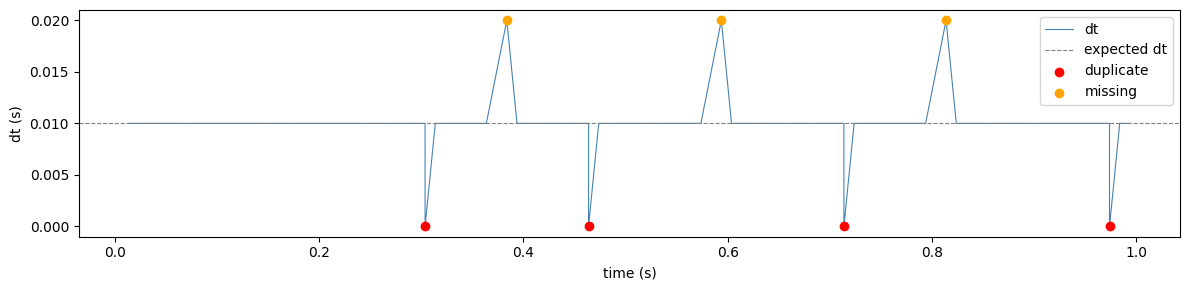

  0%|          | 0/1000 [00:02<?, ?it/s]


RuntimeError: Caught RuntimeError in DataLoader worker process 7.
Original Traceback (most recent call last):
  File "/home/aandre1/ws/torch_brain/venv/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 374, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/home/aandre1/ws/torch_brain/venv/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 57, in fetch
    return self.collate_fn(data)
  File "/home/aandre1/ws/torch_brain/venv/lib/python3.10/site-packages/torch/utils/data/_utils/collate.py", line 401, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
  File "/home/aandre1/ws/torch_brain/venv/lib/python3.10/site-packages/torch/utils/data/_utils/collate.py", line 214, in collate
    return [
  File "/home/aandre1/ws/torch_brain/venv/lib/python3.10/site-packages/torch/utils/data/_utils/collate.py", line 215, in <listcomp>
    collate(samples, collate_fn_map=collate_fn_map)
  Fi

In [184]:
from sklearn.metrics import r2_score

optim = torch.optim.AdamW(model.parameters(), lr=LR)
val_r2_history = []

for _epoch in (epoch_pbar := tqdm(range(EPOCHS))):
    model.train()
    for X, rid, Y in train_loader:
        X, Y = X.to(device), Y.to(device)
        pred = model(X, rid[0])
        loss = nn.functional.mse_loss(pred, Y)
        optim.zero_grad()
        loss.backward()
        optim.step()

    with torch.no_grad():
        model.eval()
        preds, targets = [], []
        for X, rid, Y in val_loader:
            X, Y = X.to(device), Y.to(device)
            preds.append(model(X, rid[0]))
            targets.append(Y)
        pred = torch.cat(preds).flatten(0, 1).cpu()
        target = torch.cat(targets).flatten(0, 1).cpu()
        r2 = r2_score(target, pred)
        val_r2_history.append(r2)
        epoch_pbar.set_description(f"Val R²: {r2:.3f}")

## Evaluation

Plot the R² curve over training and compare predicted vs. actual cursor velocity on one validation window.


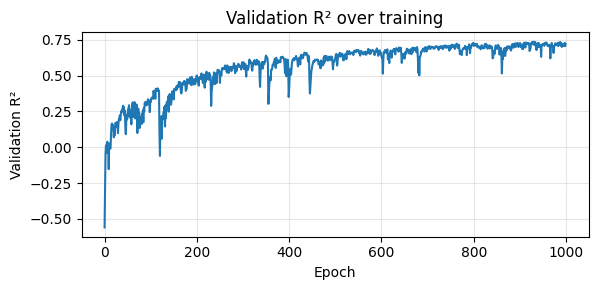

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(val_r2_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation R²")
ax.set_title("Validation R² over training")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

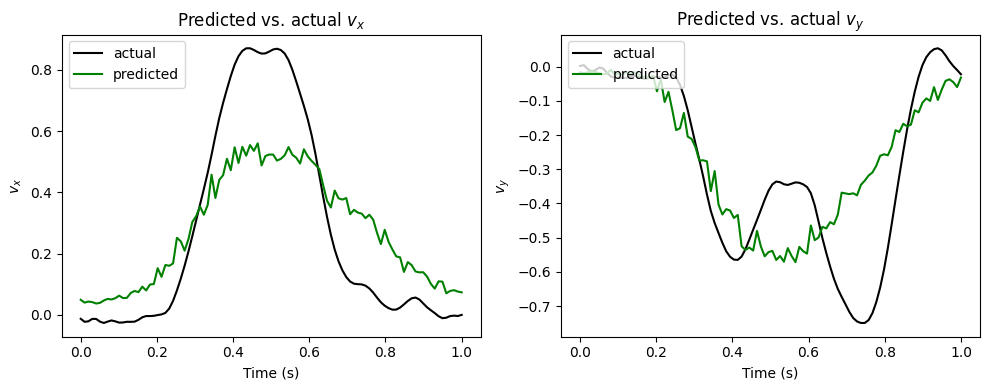

In [ ]:
model.eval()
with torch.no_grad():
    X, Y = val_ds[next(iter(val_sampler))]
    pred = model(X.unsqueeze(0).to(device)).squeeze(0).cpu()

t = np.linspace(0, WINDOW_LENGTH, Y.shape[0])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
names = ["$v_x$", "$v_y$"]

for i, name in enumerate(names):
    axes[i].plot(t, Y[:, i].numpy(), label="actual", color="k")
    axes[i].plot(t, pred[:, i].numpy(), label="predicted", color="green")
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel(name)
    axes[i].legend(loc="upper left")
axes[0].set_title("Predicted vs. actual $v_x$", usetex=False)
axes[1].set_title("Predicted vs. actual $v_y$", usetex=False)

plt.tight_layout()
plt.show()